In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import anndata as ad
import numpy as np

import scanpy as sc
import ot
from sklearn.decomposition import PCA


from GraphST import GraphST 

In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
os.environ['R_HOME']   = "/usr/lib/R"
os.environ['Renviron'] = "/usr/lib/R"

In [ ]:
n_clusters = 7 #sono 7 perchè su google ci sono 7 cluster?
dataset    = '151673' #id del dataset. non viene usato.

In [7]:
def load_data():
    h5ad_file       = '1.DLPFC/151673/scRNA.h5ad'
    expression_file = '1.DLPFC/151673/filtered_feature_bc_matrix.h5'
    oprefix         = 'DLPFC-151673'
    
    adata_gene_expression = sc.read_visium('1.DLPFC/151673', count_file='filtered_feature_bc_matrix.h5', load_images=True)
    adata_gene_expression.var_names_make_unique()
    
    return adata_gene_expression

In [8]:
adata = load_data()

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv-rpy2/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [9]:
import numpy as np
import pandas as pd
from sklearn import metrics
import scanpy as sc
import ot
from sklearn.decomposition import PCA

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2020):
    
    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']
    
    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    return adata

def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values
    
    #calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')
           
    n_cell = distance.shape[0]
    
    for i in range(n_cell):
        vec  = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh+1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)
        
    new_type = [str(i) for i in list(new_type)]    
    #adata.obs['label_refined'] = np.array(new_type)
    
    return new_type

def clustering(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01, refinement=False):

    pca = PCA(n_components=20, random_state=42) 
    embedding = pca.fit_transform(adata.obsm['emb'].copy())
    adata.obsm['emb_pca'] = embedding
    
    if method == 'mclust':
       adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
       adata.obs['domain'] = adata.obs['mclust']

    if refinement:  
       new_type = refine_label(adata, radius, key='domain')
       adata.obs['domain'] = new_type 


In [11]:
adata = ad.read_h5ad("processed_adata_cerinelli.h5ad")

In [12]:
os.environ['Renviron'] = "/usr/lib/R"
clustering(adata, n_clusters, refinement=True)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


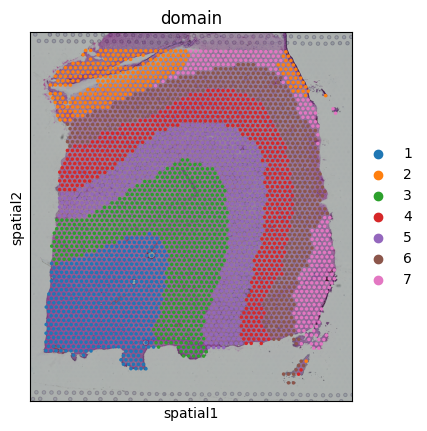

In [13]:
sc.pl.spatial(adata,
              img_key = "hires",
              color   = "domain",
              show=True)

In [26]:
original_gene_ids = np.load("transformed_gdata_gene_ids.npy")

geneIdsToSaveMainHub = [837,810,183,240,578,116,193,700,792,892,437,815,691,553,278,843]
geneIdsToSaveSmallHub = [194,703,597,731,859,399]

originalGeneIdsToSaveMainHub=[]
for i in geneIdsToSaveMainHub:
    originalGeneIdsToSaveMainHub.append(original_gene_ids[i])

print(originalGeneIdsToSaveMainHub)

originalGeneIdsToSaveSmallHub=[]
for i in geneIdsToSaveSmallHub:
    originalGeneIdsToSaveSmallHub.append(original_gene_ids[i])

print(originalGeneIdsToSaveSmallHub)



[28861, 27726, 6120, 8013, 19296, 4116, 6501, 23218, 26908, 31043, 14002, 28000, 22818, 18506, 9319, 29117]
[6546, 23243, 19815, 24099, 29638, 12869]


In [ ]:
adata_main_hub  = adata[:, originalGeneIdsToSaveMainHub].copy()
adata_small_hub = adata[:, originalGeneIdsToSaveSmallHub].copy()

In [ ]:
model = GraphST.GraphST(adata_main_hub, device=device)
adata_main_hub = model.train()

adata_main_hub.write_h5ad(filename="main_hub_close_adata")